In [ ]:
pip install Pillow tqdm matplotlib opencv-python

In [ ]:
pip install pytesseract

In [ ]:
pip install paddlepaddle paddleocr==2.8.1

In [ ]:
!pip install transformers==4.42.4

In [ ]:
!pip install torch torchvision einops

In [ ]:
!pip install timm

In [ ]:
!pip install python-doctr[torch]

In [ ]:
!pip install ollama

## **``Imports``**

In [ ]:
import os
import re
import cv2
import numpy as np
import pytesseract
import matplotlib.pyplot as plt
import ollama

from doctr.io import DocumentFile
from doctr.models import ocr_predictor
from PIL import Image
from tqdm import tqdm
from paddleocr import PaddleOCR
from PIL import Image

In [ ]:
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

In [ ]:
import transformers.dynamic_module_utils

# On intercepte le scanner d'Hugging Face et on retire "flash_attn" de la liste 
# des dépendances exigées avant même qu'il ne vérifie ton environnement.
_original_get_imports = transformers.dynamic_module_utils.get_imports

def _custom_get_imports(filename: str | os.PathLike) -> list[str]:
    imports = _original_get_imports(filename)
    if "flash_attn" in imports:
        imports.remove("flash_attn")
    return imports

transformers.dynamic_module_utils.get_imports = _custom_get_imports

## **``Config``**

In [ ]:
MAX_H = 500  # Hauteur max image pour affichage
THRESHOLD_DECOR = 0.7  # Seuil pour considérer que le code est dans la zone décor 
BASE_DIR = f"../data/dataset_ocr_packaging" 
RESOLUTIONS = [
    "150_PPP", 
    # "300_PPP", 
    # "600_PPP", 
    # "900_PPP"
]

## **``Utils``**

In [ ]:
def prepare_crops(image_path):
    """Découpe l'image en deux zones (Haut/Bas) pour doubler la résolution perçue."""
    with Image.open(image_path) as img:
        w, h = img.size
        top_crop = img.crop((0, 0, w, h // 2))
        bottom_crop = img.crop((0, h // 2, w, h))

        paths = {
            "top": "temp_top.png",
            "bottom": "temp_bottom.png"
        }
        top_crop.save(paths["top"])
        bottom_crop.save(paths["bottom"])
        
        return paths, (w, h)
    
def clean_text(text):
    return text.upper()

def get_flexible_regex(expected_ref_code):
    """
    Crée une regex qui anticipe les erreurs d'OCR (ex: 0 = O, 8 = B, 5 = S).
    Accepte aussi les sauts de ligne ou espaces au milieu du code.
    """
    # Dictionnaire de tolérance visuelle
    tolerance = {
        '0': '[0OQ]', '1': '[1Il]', '2': '[2Z]', '3': '[3E]',
        '4': '[4A]', '5': '[5S]', '6': '[6G]', '7': '[7T\?]',
        '8': '[8B]', '9': '[9g]'
    }
    
    # On traduit le code attendu en motif tolérant
    part1 = "".join([tolerance.get(c, c) for c in expected_ref_code[:4]])
    part2 = "".join([tolerance.get(c, c) for c in expected_ref_code[4:]])
    
    return rf"{part1}[\s\n\r\-\/\.]*{part2}(?:[\s\n\r\-\/\.]*\d{{3,4}})?"

def search_contracted_code(text, expected_ref_code):
    """Cherche les 4 derniers chiffres (utilisé pour les petits packs)."""
    last_4_digits = expected_ref_code[-4:]
    # On cherche les 4 chiffres isolés (frontière de mot \b)
    match = re.search(rf"\b{last_4_digits}\b", text)
    return match.group(0) if match else None


def clean_ocr_text(text):
    """Nettoie le texte extrait pour faciliter la recherche par Regex."""
    # Enlever les sauts de ligne multiples
    text = re.sub(r'\n+', '\n', text)
    return text

def extract_expected_code_from_filename(filename):
    """
    Extrait le code attendu depuis le nom du fichier.
    Ex: '241449-01_76059715_BARQ...' -> Retourne '76059715'
    """
    parts = filename.split('_')
    if len(parts) >= 2:
        return parts[1] 
    return None

def unwrap_circular_image(image_path, limit_y, temp_output="temp_unwrap.png"):
    """
    Déroule la partie supérieure de l'image (le décor) 
    pour rendre les textes courbes parfaitement horizontaux.
    """
    img_cv = cv2.imread(image_path)
    
    # Isoler la zone du décor
    decor_crop = img_cv[:int(limit_y), :]
    h, w = decor_crop.shape[:2]
    
    # Définir le centre et le rayon
    center = (w // 2, h // 2)
    radius = min(w, h) // 2
    
    # Transformée polaire : Déroulage du cercle
    unrolled = cv2.warpPolar(decor_crop, (radius, 360), center, radius, cv2.INTER_LINEAR + cv2.WARP_POLAR_LINEAR)
    
    # Rotation pour mettre le texte à l'horizontale
    unrolled_horizontal = cv2.rotate(unrolled, cv2.ROTATE_90_COUNTERCLOCKWISE)
    
    cv2.imwrite(temp_output, unrolled_horizontal)
    return temp_output


def show_hits_on_image(image, hits, limit_y):
    """Affiche l'image avec matplotlib pour éviter les crashs OpenCV dans Jupyter."""
    img_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    h, w = img_cv.shape[:2]

    scale = 1.0
    if h > 500:
        scale = 500 / h
        new_w = int(w * scale)
        img_cv = cv2.resize(img_cv, (new_w, 500))
    
    scaled_limit_y = int(limit_y * scale)
    scaled_w = img_cv.shape[1]

    cv2.line(img_cv, (0, scaled_limit_y), (scaled_w, scaled_limit_y), (0, 0, 255), 2)
    cv2.putText(img_cv, "SEUIL CARTOUCHE", (10, scaled_limit_y - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    for hit in hits:
        x_pos = 40
        y_pos = int(hit['y'] * scale)
        label = hit['text']
        
        color = (0, 255, 0) if y_pos < scaled_limit_y else (0, 165, 255)
        
        cv2.circle(img_cv, (20, y_pos), 6, color, -1)
        cv2.putText(img_cv, label, (x_pos, y_pos + 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    # Convertir BGR (OpenCV) en RGB (Matplotlib)
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    
    # Affichage inline propre pour Jupyter
    plt.figure(figsize=(12, 12))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("Visualisation Icone - Détections")
    plt.show()

## **``OCR Engines``**

In [ ]:
class TesseractEngine:
    def __init__(self, lang='fra+eng', config=r'--oem 3 --psm 11'):
        self.lang = lang
        self.config = config
        self.img = None
        self.results = None

    def extract_data(self, image_path):
        # FIX WinError 32 : On copie l'image en RAM et on libère le fichier disque
        with Image.open(image_path) as img:
            self.img = img.copy()
        
        data = pytesseract.image_to_data(self.img, lang=self.lang, config=self.config, output_type=pytesseract.Output.DICT)
        
        results = []
        for i in range(len(data['text'])):
            text = data['text'][i].strip()
            if text: 
                y_center = data['top'][i] + (data['height'][i] / 2)
                results.append({"text": text, "y": y_center})

        self.results = results
        return results, self.img.size[1] # On renvoie aussi la hauteur totale de l'image
    

class PaddleOCREngine:
    def __init__(self, lang='fr'):
        self.ocr = PaddleOCR(use_angle_cls=True, lang=lang, show_log=False)
        self.img = None
        self.results = None

    def extract_data(self, image_path):
        with Image.open(image_path) as img:
            self.img = img.copy()
            
        result = self.ocr.ocr(image_path, cls=True)
        
        results = []
        if result and result[0]:
            for line in result[0]:
                box = line[0]
                text = line[1][0]
                
                # Calcul du centre Y à partir de la bounding box (les 4 coins)
                y_coords = [point[1] for point in box]
                y_center = sum(y_coords) / len(y_coords)
                
                results.append({"text": text, "y": y_center})

        self.results = results
        return results, self.img.size[1]
    

class OllamaVLMEngine:
    def __init__(self, model_name='minicpm-v'):
        print(f"[INFO] Initialisation du VLM local via Ollama (modèle : {model_name})...")
        self.model_name = model_name

    def extract_data(self, image_path):
        with Image.open(image_path) as img:
            total_height = img.size[1]

        prompt = """
        OBJECTIVE: Extract the 8-digit Reference Code.
        FORMAT RULES:
        1. Length: Exactly 8 digits.
        2. Prefix: Must start with '76'.
        3. Layout: Can be continuous, curved, or SPLIT on 2 lines (4+4 digits). If split, merge them.
        4. Filter: Ignore weights, "150g", dates, and "Pantone".

        TASK: Focus on the technical area near the Bel logo. 
        Find the 8 digits starting with 76.
        VERIFICATION: Count the digits. If you have 7, you missed one. Look closer.

        OUTPUT: Return ONLY the 8 digits.
        """

        response = ollama.chat(
            model=self.model_name,
            messages=[{
                'role': 'user',
                'content': prompt,
                'images': [image_path]
            }],
            options={
                'temperature': 0,      
                'num_ctx': 4096,       
                'top_k': 1,           
                'top_p': 0.1
            }
        )
        text_found = response['message']['content'].strip()
        print(f"[VLM OUTPUT] {text_found}")

        return [{"text": text_found, "y": total_height * 0.3}], total_height

In [ ]:
def _clean_ocr_matches(matches):
    """nettoyer la ponctuation et les espaces des codes trouvés."""
    return [re.sub(r'[\s\n\r\-\/\.]', '', m) for m in matches]

def process_image(image_path, expected_ref_code, ocr_engine, threshold_decor=0.8, show_image=False):
    try:
        # --- 1. EXTRACTION OCR INITIALE (Scan complet) ---
        ocr_results, total_height = ocr_engine.extract_data(image_path)
        limit_y = total_height * threshold_decor
        
        # Séparation Décor / Cartouche basée sur la position Y
        decor_items = [item for item in ocr_results if item['y'] < limit_y]
        cartouche_items = [item for item in ocr_results if item['y'] >= limit_y]
        
        # Concaténation en majuscules pour la recherche
        decor_full_text = " ".join([item['text'].upper() for item in decor_items])
        cartouche_full_text = " ".join([item['text'].upper() for item in cartouche_items])
        
        print(f"[DEBUG] Texte Décor : {decor_full_text}")
        print(f"[DEBUG] Texte Cartouche : {cartouche_full_text}")

        decor_matches = []
        cartouche_matches = []
        full_ref_pattern = get_flexible_regex(expected_ref_code)

        # --- 2. RECHERCHE DANS LE CARTOUCHE ---
        cartouche_raw_matches = re.findall(full_ref_pattern, cartouche_full_text)
        if cartouche_raw_matches:
            cartouche_matches.extend(_clean_ocr_matches(cartouche_raw_matches))

        # --- 3. RECHERCHE DANS LE DECOR ---
        decor_raw_matches = re.findall(full_ref_pattern, decor_full_text)
        if decor_raw_matches:
            decor_matches.extend(_clean_ocr_matches(decor_raw_matches))
        else:
            # Tentative code contracté (4 chiffres) si rien trouvé en 8 chiffres
            contracted_val = search_contracted_code(decor_full_text, expected_ref_code)
            if contracted_val:
                decor_matches.append(contracted_val)

        # --- 4. GESTION DE L'AFFICHAGE VISUEL ---
        if show_image and (decor_matches or cartouche_matches):
            visual_hits = []
            
            # Position approximative pour les hits du décor
            for match in decor_matches:
                y_pos = next((item['y'] for item in decor_items if match[:4] in item['text'].replace(' ', '')), limit_y / 2)
                visual_hits.append({'text': f"CODE DECOR: {match}", 'y': y_pos})
                
            # Position approximative pour les hits du cartouche
            for match in cartouche_matches:
                y_pos = next((item['y'] for item in cartouche_items if match[:4] in item['text'].replace(' ', '')), limit_y + 50)
                visual_hits.append({'text': f"CODE CART: {match}", 'y': y_pos})

            show_hits_on_image(ocr_engine.img, visual_hits, limit_y)

        # --- 5. VALIDATION METIER ---
        all_matches = decor_matches + cartouche_matches
        total_count = len(all_matches)

        if total_count == 0:
            return {"success": False, "error": "ERR_NOT_FOUND", "message": "Code absent.", "matches": [], "count": 0}
        
        if cartouche_matches and not decor_matches:
            return {"success": False, "error": "ERR_MISSING_DECOR", "message": "Absent du décor packaging.", "matches": all_matches, "count": total_count}

        if decor_matches and not cartouche_matches:
            return {"success": False, "error": "ERR_MISSING_CARTOUCHE", "message": "Absent du cartouche technique.", "matches": all_matches, "count": total_count}

        return {"success": True, "error": None, "message": f"Validation réussie : {len(decor_matches)} décor, {len(cartouche_matches)} cartouche.", "matches": all_matches, "count": total_count}

    except Exception as e:
        return {"success": False, "error": "ERR_SYSTEM", "message": str(e), "matches": [], "count": 0}

## **``Main program``**

In [ ]:
engine_tesseract = TesseractEngine(
    lang='fra+eng',
    config=r'--oem 3 --psm 3'
)
engine_paddle = PaddleOCREngine(lang='fr')
engine_vlm = OllamaVLMEngine(model_name='minicpm-v')

In [21]:
def main(engine, show_image=False):
    print("[INFO] Lancement du POC OCR - Vérification des codes packaging")
    print(f"[INFO] Utilisation du moteur OCR : {engine.__class__.__name__}")
    print("-" * 60)
    
    for doc_type in tqdm(os.listdir(BASE_DIR), desc="Traitement des types de documents"):
        doc_path = os.path.join(BASE_DIR, doc_type)
        if not os.path.isdir(doc_path):
            continue
        
        for res_folder in RESOLUTIONS:
            folder_path = os.path.join(doc_path, res_folder)
            if not os.path.exists(folder_path):
                continue
                
            for filename in os.listdir(folder_path):
                if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue
                    
                image_path = os.path.join(folder_path, filename)
                expected_ref = extract_expected_code_from_filename(filename)
                
                if not expected_ref:
                    continue

                print(f"\nFichier : {filename} | Attendu : {expected_ref}")
                
                result = process_image(image_path, expected_ref, engine, threshold_decor=THRESHOLD_DECOR, show_image=show_image)
                
                # FALLBACK : 8 ROTATIONS 
                if not result['success']:
                    print(f"[RETRY] Code non trouvé à 0°. Tentative de rotation forcée...")
                    # On teste 45, 90, 135, 180, 225, 270, 315
                    angles = [90, 180, 270, 45, 135, 225, 315] 
                    
                    for angle in angles:
                        print(f"  -> Test rotation {angle}°...")
                        with Image.open(image_path) as img:
                            # expand=True pour ne pas couper les coins lors de la rotation
                            rotated_img = img.rotate(angle, expand=True)
                            temp_path = f"temp_rot_{angle}.png"
                            rotated_img.save(temp_path)
                        
                        result = process_image(temp_path, expected_ref, engine, threshold_decor=THRESHOLD_DECOR, show_image=show_image)
                        
                        if os.path.exists(temp_path):
                            os.remove(temp_path)
                            
                        if result['success']:
                            print(f"  [SUCCESS] Code trouvé après rotation de {angle}° !")
                            break 
                
                status = "OK" if result['success'] else "FAIL"
                print(f"Résultat final : {status} | {result['message']}")
                if 'matches' in result:
                    print(f"  Codes validés : {result['matches']}")
                
    print("-" * 60)
    print("[INFO] Fin du traitement.")

[INFO] Lancement du POC OCR - Vérification des codes packaging
[INFO] Utilisation du moteur OCR : TesseractEngine
------------------------------------------------------------


Traitement des types de documents:   0%|          | 0/5 [00:00<?, ?it/s]


Fichier : 241449-01_76059715_BARQ_LVQR_ORIGI_150G_NORDI_150ppp.png | Attendu : 76059715
[DEBUG] Texte Décor : © OP NARBONNE CET MT ET JONC ROUPEE.CON RU OAD HOCK MN ME ECC NEL DANSER TIP PBA 4 EE PRESSE /EMIERENT À ‘ARAVA ET HEU MATE 2 IPPNING, KONSUMERAS INOM 5 DA HE MALT SAL. FELT ET: “TYE CPG [SOAPS TON EEN. AL PAN, SAT DIN ES EVE) IT A AT LEE RM TERMS ST OTA EU E00) “TE RAR) AE NG PTS RAS: HE. PF LE I SS MSN, CE) 76059715 - _ SENNA PES FOR USTA: 2 L MEAT SERIE ANS INTE YT BAND AE + MN D AE FW SOFEZ EEE 9 ES IS} LEE NN 8, 3 FAWN (SE ETE. OO FOES AN SIE INTE NON NI SE AT DEN 5 À EEN ERIC CATON ATONE 5528 RES F = NN N 5 00 9 OO O N TANNING? AT ONIN YP TRE + O OD ~. RER > © — IMPORTED INGREDIENTS. NOS — BELS.A-BP.4-921TSURESNES CEDEK-FRANCE MW GRAUPE-BELCOM KEEP RER 0"> GUENSEY /3324/2P24 ‘YSOY)EULS AE SANE LIN AE WNIDIUG JL MM PLAN TECHNICAL DRAWING
[DEBUG] Texte Cartouche : CYAN YELLOW BLACK PANTONE 7685 C 27917MM 2400.MM 12415MM 1949.1, MM MM 52% 45% 23% 36% % BEL SA PREMEDIA CONTA

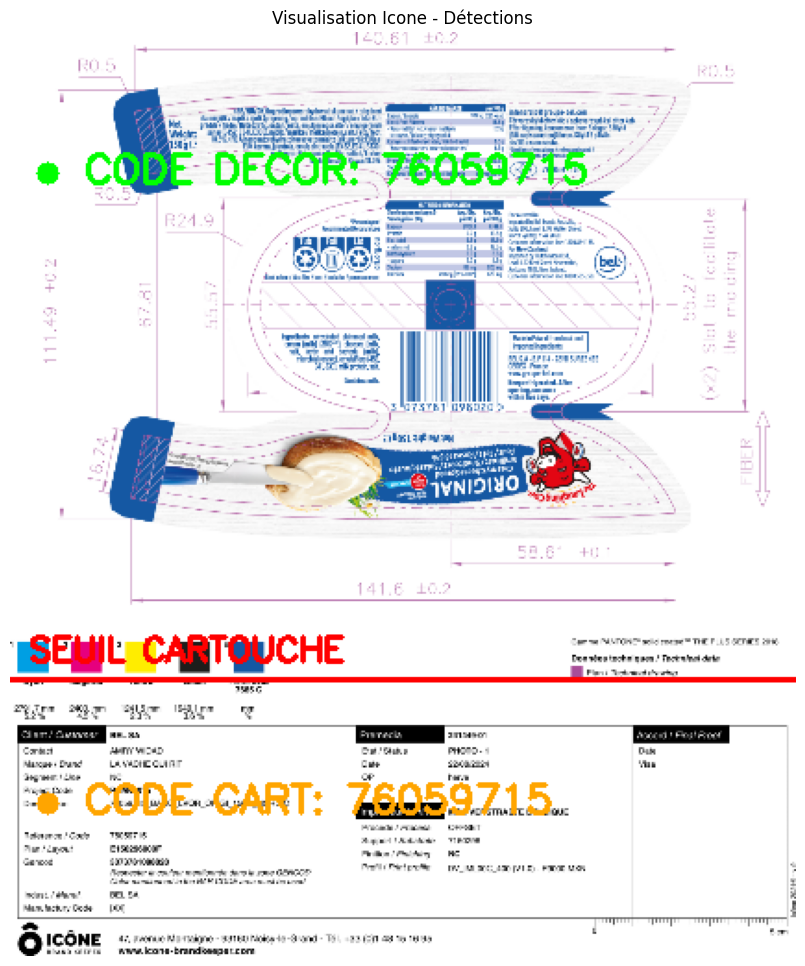

Traitement des types de documents:  40%|████      | 2/5 [00:01<00:02,  1.01it/s]

Résultat final : OK | Validation réussie : 1 décor, 2 cartouche.
  Codes validés : ['76059715', '76059715', '76059715']

Fichier : 241497-06_76059533__529_CEL_MBY_RSM_RGE_FR_150ppp.png | Attendu : 76059533
[DEBUG] Texte Décor : < > 9 11 14 9 <>< >> AA Y À 5 É 3 X, É E| 8 FA 760598331529 76059533/529 76059883/529 760506331529
[DEBUG] Texte Cartouche : BLANCI BLANC2 80252MM 75136MM 1373.6MM 1438,5 MM 25% 23% 24% 184% 1 YELLOW CYAN MAGENTA ROUGE BLACK CELLO 8224MM 258157MM 539.9 MM 14% 3.% % GAMME PANTONE® SOLID COATED™ THE PLUS SERIES 2018 DONNÉES TECHNIQUES / TECHNICAL DATA M PIAN / TECHNICAL DRAWING BELSA PREMEI 241497-06 ACCORD / FINAL PROOF CONTACT AMRY WIDAD ETAT/ STATUS PHOTO 1 MARQUE / BRAND MINI BABYBEL DATE 08/08/2024 VISA SEGMENT/ LINE NC OP ICONEDO PROJECT CODE PAMA8194 DESIGNATION 76059533 529_CEL_MBY_RSM_RGE_FR IMPRIMEUR / PRINTER BEC CELLPACK ILLFURTH PROCÉDÉ / PROCESS FLEXO REFERENCE / CODE 76059533 529 SUPPORT/ SUBSTRATE 7420002 7420110 PLAN / LAYOUT PE_E42006331HPLF FINI

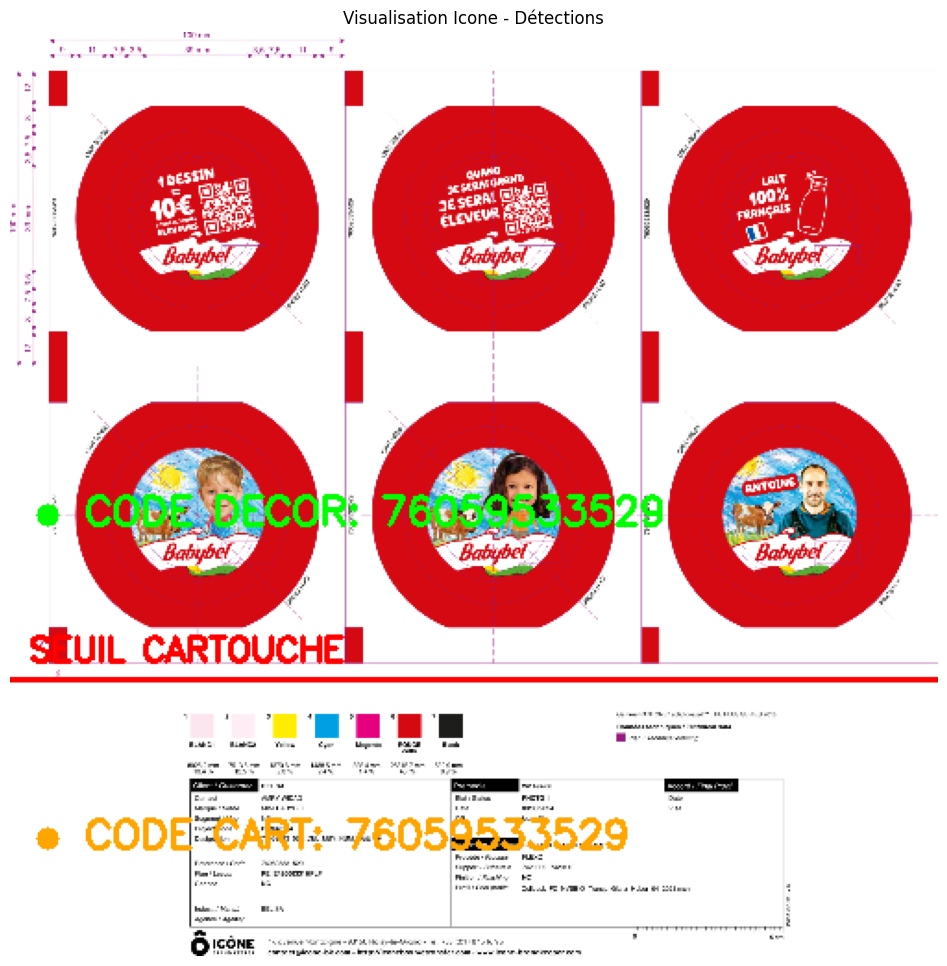

Traitement des types de documents:  60%|██████    | 3/5 [00:03<00:02,  1.15s/it]

Résultat final : OK | Validation réussie : 1 décor, 2 cartouche.
  Codes validés : ['76059533529', '76059533529', '76059533529']

Fichier : 241995-01_76060096_DSQIMPS_LVQR_AFH_PLANT_BASED_8P_150ppp.png | Attendu : 76060096
[DEBUG] Texte Décor : INSIDE @102.3 LIMIT PRINTING 9109 (A) BOX FORMED @111.2 SPREADABLE CHEESE ALTERNATIVE DS MIES GARLIC 5 HERE BY / JIANEWA ILMONDMILK LIMIT PRINTING @126 (B) DISK DIAMETER ©129,3 TO THE TABLE IN THE LEFT PART. 1 2 3 4 GAMME PANTONE® SOLID COATED™ THE PLUS SERIES 2018 | | | | | | PANNÉES TECHNIQUES/ TECHNICAL DATA MM PIAN / TECHNICA DRAWING CYAN MAGENTA YELLOW BLACK PANTONE PANTONE 2262 C 2068 C
[DEBUG] Texte Cartouche : MM MM MM MM MM MM MM MM MM MM % % % % % % % % % BEL SA PREMEDIA 241995-01 CONTACT SCHEFFTER_MARION ETAT / STATUS PHOTO 3 MARQUE / BRAND LA VACHE QUI RIT DATE O7/OR024 VISA SEGMENT / LINE NC OP GRI PROJECT CODE PAM48732 DESIGNATION 76060096 DSQIMPS_LVGR_AFH_PLANT_BASED_8P CARRE LACROIX POLAND OSDRUCK PROCÉDÉ / PROCESS OFFSET SUPPORT

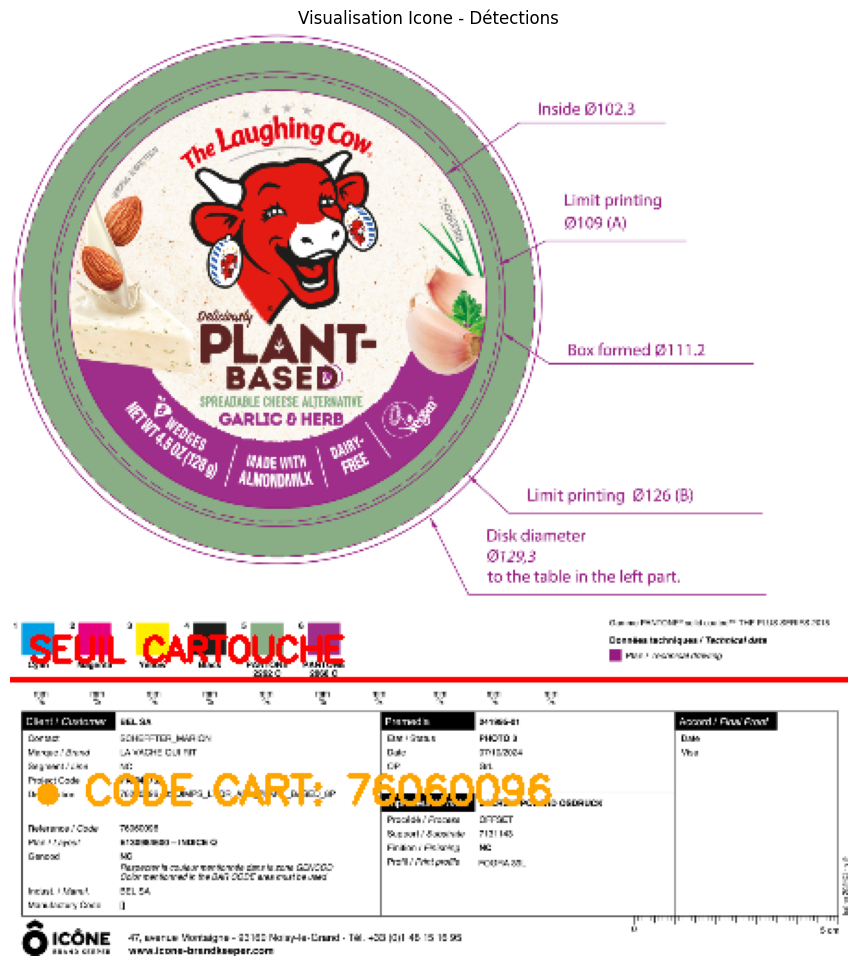

[RETRY] Code non trouvé à 0°. Tentative de rotation forcée...
  -> Test rotation 90°...
[DEBUG] Texte Décor : PTE WOS 5 $691 SI 8 L(O) EE+ 1E - PUELD-SI-ASION PESN AQ JSNW BALE 6E VUD04 COON OU ON BUYSTUTD | YOUS SLIGLZ EXEUSQNS / WODDNG 438440 HONHASO ANVIOD XIOHOVI SS09014 | 9P9901D 48 G3SVE INVID V9 BSIA, YE0Z/01/Z0 EQ € O1OHD SELS / 1213, LO-S661B2 % % % % % % WITS WITS WITS WS WITS WS 98902 92877 BNOINYD 3NOLNYD GUMEUP REORUYOE | UEID [I EE EE EEE = || 9 8102 SAIMAS SD 3H «P8209 PLLOS ,ANOLNVA OWED “ED YO] AU} UL AJQE} AY} 0} £6710 JAJAWELP HSIQ (2) 9Z71@ 6UYUYD UR] 33 WONOWTY BO HUM UAH 8 IALWNUALIV 3S33H9 T'LLLG PEUHO} XOG (V) 6010 BUNUUD UR] £'TOLG EPISU|
[DEBUG] Texte Cartouche : WOD'1EDEEXPUBIG-CUOS/ MMM 3933X ONVES 08186 - EUBIEMUON ENUENE VY ANODI L 4 U SPO9 AIMOENUEYY VST38 UEN ISMPUL 3009 HV OU LI PEUUOUEW! 10/0 SU A ARE EEE 9 D 391QNI - OOSVASOETA INOFE7 | UELA 2600909/ @P0G / SOUSIAJEUS HAY HOAT SDNIOSC 96009092 UONEUBISEQ ZEZERIVD EPO9 ROELO1G ‘ON EURY SUEWIBEG 414 IND

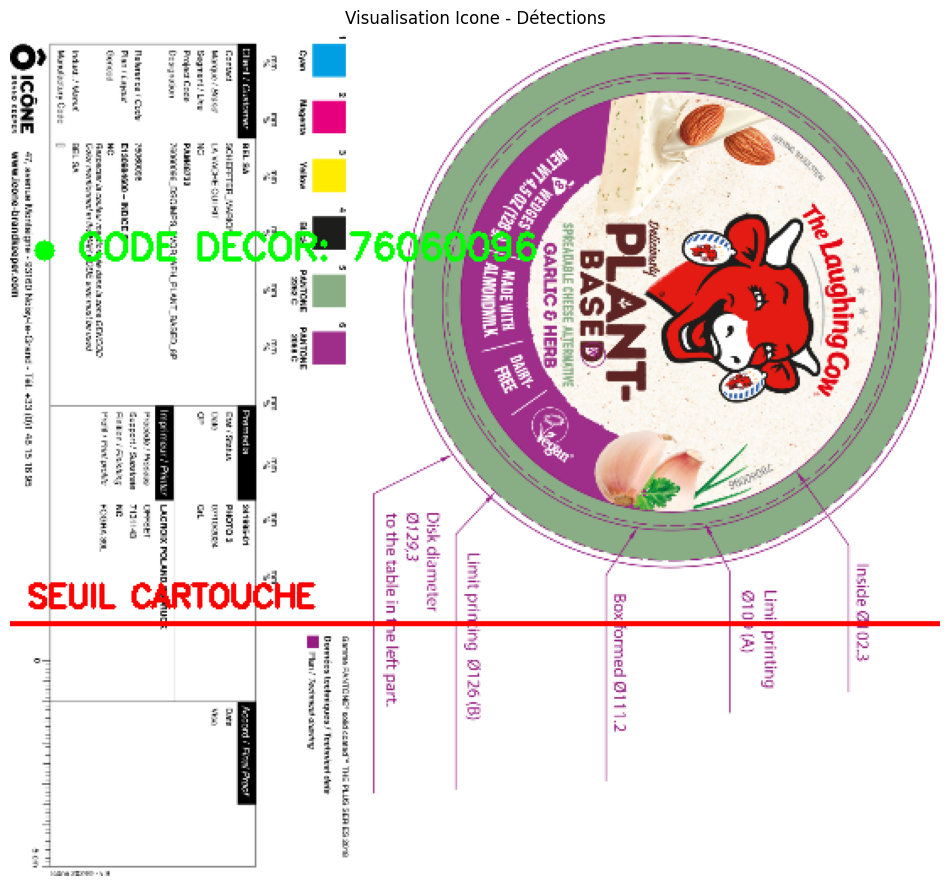

  -> Test rotation 45°...
[DEBUG] Texte Décor : 
[DEBUG] Texte Cartouche : 
  -> Test rotation 135°...
[DEBUG] Texte Décor : 
[DEBUG] Texte Cartouche : 
  -> Test rotation 225°...
[DEBUG] Texte Décor : 
[DEBUG] Texte Cartouche : 
  -> Test rotation 315°...


Traitement des types de documents:  80%|████████  | 4/5 [00:10<00:03,  3.41s/it]

[DEBUG] Texte Décor : LATE HETWTA SOLS
[DEBUG] Texte Cartouche : 
Résultat final : FAIL | Code absent.
  Codes validés : []

Fichier : 241251-02_76059129_ETQFIL_MBY_RED_F12_NOEL_2024_BE_LU_150ppp.png | Attendu : 76059129
[DEBUG] Texte Décor : VALEURS NUTONNELES | VEEDNGRVOADEN POA NE IRLO ) EA CE C) EEN GE HONE VEGETARISCH SREMSEL CIE FRE EEN MAGISCH ““@ “AH MENT UC A AEANSOMMER DE PRÉFÉRENCE AVANT LE TEN MINSTE HOUDAAR TT /MINDESTANS HALTBAR BIS 54 MM COULEURS RECTO CYAN MAGENTA YELLOW
[DEBUG] Texte Cartouche : GAMME PANTONE® SOLID COATED™ THE PLUS SERIES 2018 DONNÉES TECHNIQUES / TECHNICAL DATA I PIAN / TECHNICAL DRAWING BEL SA PREMEDIA 241251-02 ACCORD / FINAL PROOF CONTACT AUFORT_MURIEL ETAT / STATUS REPRO1 DATE MARQUE / BRAND MINIBABYBEL DATE 17/07/2024 VISA SEGMENT / LINE NC OP ICONET9 PROJECT CODE PAM47830 DESIGNATION 76059129 _ETOFIL_ MBY_RED_F12 NOEL 2024 BE LU IMPRIMEUR / PRINTER EEE PROCÉDÉ / PROCESS FLEXO SUPPORT / SUBSTRATE 7210230 FINITION / FINISHING NC REFERENCE / CODE 

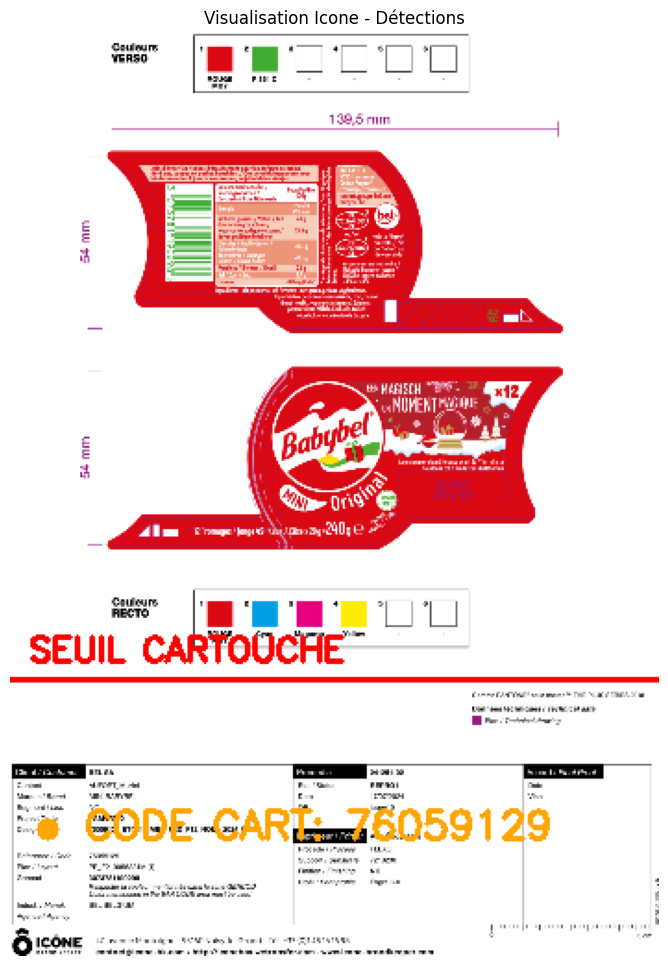

[RETRY] Code non trouvé à 0°. Tentative de rotation forcée...
  -> Test rotation 90°...
[DEBUG] Texte Décor : RENS 110919 D99YPUD1Q-SUOII MMM - O9" 13JSUDIISM XOQBUOI!, G6 91 SL BY L(O) £E+ “IAL - PUDID-2)-ASION WOS OUT PASN 8Q ISN GOONFD 8U0Z E] 716€ 22604 EYOUD JU LD ON GUYSIU | OU 0620122 EEUSANS | UODDNG OX314 SS8901D | 9P99014 SONONBNA AAY FEAT 139 +202 TION GHUO9! BSIA PZ0Z/LO/LL TOUDAY 10044 [BUL | PAO9OW ZO-1SZI¥Z BIPOWELD GUMESP 1EOUUOE / UED EJEP [89/4981 / SENBJUYOE} SEGUUOQ 8102 SAIU3S SNID SHI MP8IEOO POS ,ANOLNVA EUWED AGN - - MOLE, EUBEN UEKO AONOU 9 S © PAR £: 8 3 ZD I N WU G'6EL JAN [ 7 7 9 19€ D 39N04 ° 8 , E
[DEBUG] Texte Cartouche : *DYY + W09"AQ-2U091@49DIU09 OOLEG - SUBDIUON ANUAAD ‘77 V23433% ONVES 3NO9I ~ ‘AOUSBY | EOUSBY NNI9738 738 YNUEYY | SNPU} BARE 3000 UVA AU UI PEUUORUEUL 10/09 SUEP EGUUO!JUEUI JN8IN09 E] 18128584 B6Z06L8ZEL0E COTE] - (D) WIEESSOOLZA 34 NOAET | UEID 62165082 EP09 / SOUEIEJEN 211 QI ASW 11013 62465092 UONEUBISEQ OEEZYWVD EPO9 181014 ON EUR

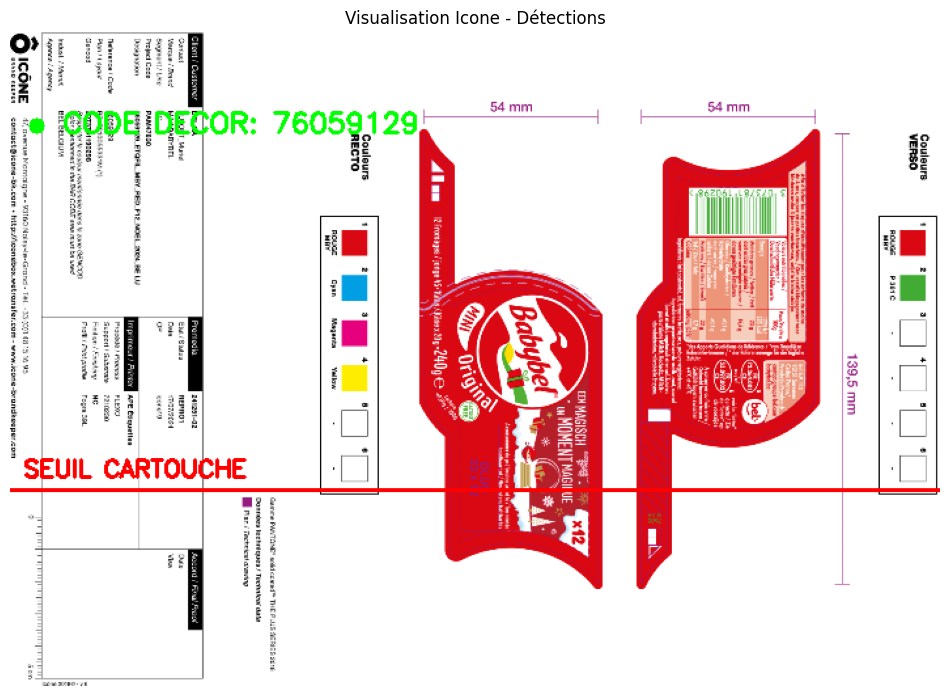

  -> Test rotation 45°...
[DEBUG] Texte Décor : * ER A, «2E N, RS SEITE, SE CA
[DEBUG] Texte Cartouche : 
  -> Test rotation 135°...
[DEBUG] Texte Décor : 
[DEBUG] Texte Cartouche : 
  -> Test rotation 225°...
[DEBUG] Texte Décor : 
[DEBUG] Texte Cartouche : 
  -> Test rotation 315°...


Traitement des types de documents: 100%|██████████| 5/5 [00:18<00:00,  3.76s/it]

[DEBUG] Texte Décor : 
[DEBUG] Texte Cartouche : 
Résultat final : FAIL | Code absent.
  Codes validés : []
------------------------------------------------------------
[INFO] Fin du traitement.


In [22]:
main(engine=engine_tesseract, show_image=True)

In [ ]:
# Rajouter nombre d'occurence dans la detection des codes 
# Code barre peu etre different de la cartouche uniquement 